In [26]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import logging
import time
import seaborn as sns
from sklearn.decomposition import PCA, TruncatedSVD

In [3]:
# Set up logging
# This configuration is for all modules that are in the same Python process, so it will affect all logging calls in this notebook
# To ensure all files use the same logging configuration, we can create a main.py file that sets up logging and then import the logger from there in all other files. 
logging.basicConfig(level=logging.INFO,
                    # filename='autoencoder_training.log',
                    # filemode='w',
                    format='%(levelname)s: %(message)s',
                    force=True) # Force reconfiguration to ensure settings are applied

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"Using device: {device}")

INFO: Using device: cpu


In [6]:
logger = logging.getLogger(__name__) # Create a logger for the current file
logger.setLevel(logging.INFO) # Set the logging level to INFO for this logger
logger.info(f"Logger name: {logger.name} and level: {logging.getLevelName(logger.level)}") # Log the logger's name and level to verify configuration

INFO: Logger name: __main__ and level: INFO


In [174]:
class AE_preprocessing_pipeline():
    def __init__(self, dataset_path):
        self.dataset_df = self.load_data(dataset_path)
        self.feature_cols = None
        self.cyclic_cols = None
        self.binary_cols = None
        self.lag_cols = None

        if self.dataset_df is not None:
            self.remove_nan()
            self.remove_uninformative_features()
            self.identify_features()
        else:
            logger.warning("Dataset could not be loaded. Preprocessing steps will be skipped.")
    
    def load_data(self, dataset_path):
        dataset = pd.read_csv(dataset_path)

        if dataset.empty:
            logger.warning("The loaded DataFrame is empty. Please check the file path and contents.")
            return None
        else:
            logger.info(f"Data loaded successfully with shape: {dataset.shape}")
            logger.info(f'DataFrame columns: {dataset.columns.tolist()}')

        return dataset
    
    def remove_nan(self):
        initial_shape = self.dataset_df.shape
        self.dataset_df.dropna(inplace=True)
        logger.info(f"Removed NaN values. Shape changed from {initial_shape} to {self.dataset_df.shape}")

    def remove_uninformative_features(self):
        uninformative_cols = ['latitude_y', 'longitude_y', 'city', 'state', 'month', 'day', 'hour', 'day_of_week', 'day_of_year']
        self.dataset_df.drop(columns=uninformative_cols, inplace=True)
        logger.info(f"Removed uninformative features: {uninformative_cols}")

    def identify_cyclic_features(self):
        cyclic_postfixes = ['_sin', '_cos']
        self.cyclic_cols = [col for col in self.dataset_df.columns if any(col.endswith(postfix) for postfix in cyclic_postfixes)]
        logger.info(f"Identified cyclic features: {self.cyclic_cols}")

    def identify_binary_features(self):
        self.binary_cols = [col for col in self.dataset_df.columns if self.dataset_df[col].nunique() == 2 and col not in self.cyclic_cols]
        logger.info(f"Identified binary features: {self.binary_cols}")

    def identify_lag_features(self):
        lag_prefixes = [
            'us_aqi_past_',
            'pm2_5_past_',
            'ozone_past_',
            'wind_speed_10m_past_',
            'wind_direction_10m_sin_past_',
            'wind_direction_10m_cos_past_',
        ]
        self.lag_cols = [col for col in self.dataset_df.columns if any(col.startswith(prefix) for prefix in lag_prefixes)]
        logger.info(f"Identified lag features: {self.lag_cols}")

    def identify_feature_cols(self):
        remove_cols = ['zip', 'time', 'us_aqi'] + self.cyclic_cols + self.binary_cols + self.lag_cols
        self.feature_cols = [col for col in self.dataset_df.columns if col not in remove_cols]
        logger.info(f"Feature columns: {self.feature_cols}")
        logger.info(f"Number of feature columns: {len(self.feature_cols)}")
    
    def identify_features(self):
        self.identify_cyclic_features()
        self.identify_binary_features()
        self.identify_lag_features()
        self.identify_feature_cols()


    def split_data(self, train_size=0.8):
        train_splits = []
        val_splits = []
        train_df = None
        val_df = None

        for zip_code, group in self.dataset_df.groupby('zip'):
            group = group.sort_values('time').reset_index(drop=True)
            split_index = int(len(group) * train_size)

            train_splits.append(group.iloc[:split_index])
            val_splits.append(group.iloc[split_index:])

        train_df = pd.concat(train_splits, axis=0).reset_index(drop=True)
        val_df = pd.concat(val_splits, axis=0).reset_index(drop=True)

        logger.info(f"Training split shape: {train_df.shape}")
        logger.info(f"Validation split shape: {val_df.shape}")

        return train_df, val_df
    
    def scale_features(self, train_df, val_df, scaler=MinMaxScaler()):
        X_train_scaled = scaler.fit_transform(train_df[self.feature_cols])
        X_val_scaled = scaler.transform(val_df[self.feature_cols])
        logger.info(f"Features scaled using {scaler.__class__.__name__}.")

        return X_train_scaled, X_val_scaled

    def convert_to_tensors(self, X_train_scaled, X_val_scaled):
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        logger.info("Data converted to PyTorch tensors successfully.")

        return X_train_tensor, X_val_tensor

In [151]:
class EarlyStopping:
  def __init__(self, patience=5):
    self.patience = patience
    self.counter = 0
    self.best_loss = float("inf")
    self.best_state = None
  
  def step(self, model, val_loss):
    if(val_loss < self.best_loss):
      self.best_loss = val_loss
      self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
      self.counter = 0
      return False
    else:
      self.counter += 1
      return self.counter >= self.patience

class TimeVariantAutoencoder(nn.Module):
    def __init__(self, input_dim, scaler=MinMaxScaler, hidden_layers=[128, 64]):
        super(TimeVariantAutoencoder, self).__init__()
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers[:-1]:
            encoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            encoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim
        encoder_layers.append(nn.Linear(prev_dim, hidden_layers[-1])) # Final layer to latent space
        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        prev_dim = hidden_layers[-1]
        for hidden_dim in reversed(hidden_layers[:-1]):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_layers.append(nn.ReLU())
            prev_dim = hidden_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers, nn.Sigmoid()) if scaler == MinMaxScaler else nn.Sequential(*decoder_layers)

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

In [152]:
class AETrainer:
    def __init__(self, input_dim, scaler=MinMaxScaler, hidden_layers=[128, 64]):
        self.model = TimeVariantAutoencoder(input_dim=input_dim, scaler=scaler, hidden_layers=hidden_layers).to(device)

    def compile(self, optimizer, loss_fn):
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.earlystopper = EarlyStopping()
    
    def loader(self, X, batch_size=1048, shuffle=True):
        dataset = TensorDataset(X)
        return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    
    def fit(self, X, val, num_epochs=50):
        history = {'train_loss': [], 'val_loss': [], 'best_loss': float('inf'), 'training_time': 0}
        start_time = time.time()

        for epoch in range(num_epochs):
            self.model.train() # Set the model to training mode
            epoch_loss = 0.0
            
            train_loader = self.loader(X)
            val_loader = self.loader(val, shuffle=False)
            
            for (X_batch, )in train_loader:
                _, reconstructed = self.model.forward(X_batch)

                self.optimizer.zero_grad()
                loss = self.loss_fn(reconstructed, X_batch)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item() * X_batch.size(0) # Accumulate loss
            
            avg_loss = epoch_loss / len(train_loader.dataset) # Average loss for the epoch
            history['train_loss'].append(avg_loss)

            val_loss = self.validate(val_loader)
            history['val_loss'].append(val_loss)

            if (epoch + 1) % 10 == 0 or epoch == 0: # Log every 10 epochs and the first epoch
                logger.info(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_loss:.8f}, , Val Loss: {val_loss:.8f}')

            if(self.earlystopper.step(self.model, val_loss)):
              logger.info(f"Early stopping at epoch {epoch+1}")
              break
        end_time = time.time()

        if self.earlystopper.best_state is not None:
            self.model.load_state_dict(self.earlystopper.best_state)

        history['training_time'] = end_time - start_time
        history['best_loss'] = self.earlystopper.best_loss
        return history

    def validate(self, test):
        self.model.eval() # Set the model to evaluation mode
        val_loss = 0.0
        with torch.no_grad():
            for (X_batch, )in test:
                _, reconstructed = self.model.forward(X_batch)
                loss = self.loss_fn(reconstructed, X_batch)
                val_loss += loss.item() * X_batch.size(0) # len(X_batch) is the number of samples in the batch, so we multiply by it to get the total loss for that batch
        avg_loss = val_loss / len(test.dataset) # Average loss for the test set
        #logger.info(f'Val Loss: {avg_loss:.8f}')
        return avg_loss

            

In [186]:
hidden_layers = [
    #[8],
    #[4],
    [2],
    [16, 4],
    [8, 2],
    [16, 4, 2]
]

In [183]:
ae_preprocess = AE_preprocessing_pipeline(dataset_path='../datasets/all_features_all_data.csv')
train_df, val_df = ae_preprocess.split_data()

INFO: Data loaded successfully with shape: (79152, 193)
INFO: DataFrame columns: ['city', 'state', 'zip', 'latitude_x', 'longitude_x', 'time', 'us_aqi', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'uv_index_clear_sky', 'uv_index', 'dust', 'aerosol_optical_depth', 'temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m', 'shortwave_radiation', 'diffuse_radiation', 'cloud_cover', 'road_distance_m', 'road_impact_score', 'facility_count_nearby', 'facility_impact_score', 'overall_spatial_impact_score', 'month', 'month_sin', 'month_cos', 'day', 'hour', 'hour_sin', 'hour_cos', 'day_of_week', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year', 'is_weekend', 'wind_direction_10m_sin', 'wind_direction_10m_cos', 'wind_direction_100m_sin', 'wind_direction_100m_cos', 'latitude_y', 'longitude_y', 'us_aqi_past_1', 'us_aqi_past_2', 'us_aqi_past_3', 'us_aqi_past_4', 'us_aqi_past_5', 'us_aqi_past_6', 'us_aqi_

In [184]:
X_train_scaled, X_val_scaled = ae_preprocess.scale_features(train_df, val_df)
X_train_tensor, X_val_tensor = ae_preprocess.convert_to_tensors(X_train_scaled, X_val_scaled)

INFO: Features scaled using MinMaxScaler.
INFO: Data converted to PyTorch tensors successfully.


In [182]:
X_train__std, X_val__std = ae_preprocess.scale_features(train_df, val_df, scaler=StandardScaler())
X_train_tensor_std, X_val_tensor_std = ae_preprocess.convert_to_tensors(X_train__std, X_val__std)

INFO: Features scaled using StandardScaler.
INFO: Data converted to PyTorch tensors successfully.


In [188]:
def run_experiment(X_train_tensor, X_val_tensor, hidden_layers, scaler_name):
    logger.info(f"Training autoencoder with hidden layers: {hidden_layers}")
    trainer = AETrainer(input_dim=X_train_tensor.shape[1], scaler=MinMaxScaler if scaler_name == 'MinMaxScaler' else StandardScaler, hidden_layers=hidden_layers)
    trainer.compile(optimizer=torch.optim.Adam(trainer.model.parameters(), lr=0.001), loss_fn=nn.MSELoss())
    history = trainer.fit(X_train_tensor.to(device), X_val_tensor.to(device), num_epochs=50)
    return history

In [228]:
import matplotlib.patches as mpatches

def plot_reconstruction_comparison(ae_results, pca_results, svd_results, latent_dim=None):
    autoencoder_train_mses = [min(ae_results[name]['train_loss']) for name in ae_results.keys()]
    autoencoder_val_mses = [min(ae_results[name]['val_loss']) for name in ae_results.keys()]

    pca_train_mse = [pca_results[dim]['train'] for dim in pca_results.keys()]
    svd_train_mse = [svd_results[dim]['train'] for dim in svd_results.keys()]

    pca_val_mse = [pca_results[dim]['val'] for dim in pca_results.keys()]
    svd_val_mse = [svd_results[dim]['val'] for dim in svd_results.keys()]

    train_mses = autoencoder_train_mses + pca_train_mse + svd_train_mse
    val_mses   = autoencoder_val_mses + pca_val_mse + svd_val_mse

    x = np.arange(len(train_mses))
    width = 0.35
    colors = ['blue'] * len(autoencoder_train_mses) + ['red'] * len(pca_train_mse) + ['green'] * len(svd_train_mse)

    plt.figure(figsize=(10, 6))

    bars1 = plt.bar(x - width/2, train_mses, width, label='Train MSE', color=colors)
    bars2 = plt.bar(x + width/2, val_mses, width, label='Val MSE', color=colors, hatch='//')

    labels = list(ae_results.keys()) + list(pca_results.keys()) + list(svd_results.keys())
    plt.xticks(x, labels)
    plt.ylabel('Reconstruction MSE')
    
    if latent_dim is not None:
        plt.title(f'Reconstruction MSE: Autoencoders vs PCA vs SVD\n(Latent dim = {latent_dim})')
    else:
        plt.title('Reconstruction MSE: Autoencoders vs PCA vs SVD')

    plt.yscale('log')
    plt.legend()
    plt.grid(True, axis='y')

    for bar, v in zip(bars1, train_mses):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{v:.4f}',
            ha='center',
            va='bottom'
        )

    for bar, v in zip(bars2, val_mses):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{v:.4f}',
            ha='center',
            va='bottom'
        )

    ae_patch  = mpatches.Patch(color='blue',  label='Autoencoder')
    pca_patch = mpatches.Patch(color='red',   label='PCA')
    svd_patch = mpatches.Patch(color='green', label='SVD')

    train_patch = mpatches.Patch(facecolor='gray', label='Train MSE')
    val_patch   = mpatches.Patch(facecolor='gray', hatch='//', label='Val MSE')

    plt.legend(handles=[ae_patch, pca_patch, svd_patch, train_patch, val_patch])

    plt.tight_layout()
    plt.show()


In [214]:
def plot_ae_loss_curves(full_results, latent_dim=None):
    plt.figure(figsize=(10, 6))

    for architecture, result in full_results.items():
        plt.plot(result['train_loss'], label=architecture)

    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')

    if latent_dim is not None:
        plt.title(f'Autoencoder Training Loss by Architecture\n(Latent dim = {latent_dim})')
    else:
        plt.title('Autoencoder Training Loss by Architecture')

    plt.legend(title='Hidden Layers')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [204]:
def log_reconstruction_summary(results, logger):
    autoencoder_runs = [k for k in results.keys() if k not in ['PCA', 'SVD']]
    all_runs = autoencoder_runs + ['PCA', 'SVD']

    logger.info(f"{'Method':<25} {'Train MSE':>12} {'Val MSE':>12}")
    for name in all_runs:
        logger.info(f"{name:<25} {results[name]['train']:>12.6f} {results[name]['val']:>12.6f}")

In [205]:
def pca(X_train_scaled, X_val_scaled, n_components=2):
    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_train_pca_recon = pca.inverse_transform(X_train_pca)

    # Calculate reconstruction MSE for training data
    pca_mse_train = np.mean((X_train_scaled - X_train_pca_recon) ** 2)
    logger.info(f"PCA reconstruction MSE (train): {pca_mse_train:.6f}")
    logger.info(f"PCA explained variance ratio: {pca.explained_variance_ratio_.sum():.3f}")

    # Apply to test data
    X_val_pca = pca.transform(X_val_scaled)
    X_val_pca_recon = pca.inverse_transform(X_val_pca)
    pca_mse_val = np.mean((X_val_scaled - X_val_pca_recon) ** 2)
    logger.info(f"PCA reconstruction MSE (val): {pca_mse_val:.6f}")
    return pca_mse_train, pca_mse_val

In [206]:
def svd(X_train_scaled, X_val_scaled, n_components=2):
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    X_train_svd = svd.fit_transform(X_train_scaled)
    X_train_svd_recon = svd.inverse_transform(X_train_svd)

    # Calculate reconstruction MSE for training data
    svd_mse_train = np.mean((X_train_scaled - X_train_svd_recon) ** 2)
    logger.info(f"SVD reconstruction MSE (train): {svd_mse_train:.6f}")
    logger.info(f"SVD explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

    # Apply to test data
    X_val_svd = svd.transform(X_val_scaled)
    X_val_svd_recon = svd.inverse_transform(X_val_svd)
    svd_mse_val = np.mean((X_val_scaled - X_val_svd_recon) ** 2)
    logger.info(f"SVD reconstruction MSE (val): {svd_mse_val:.6f}")
    return svd_mse_train, svd_mse_val

In [211]:
results_minmax = {}

for hidden_layer_config in hidden_layers:
    history = run_experiment(X_train_tensor, X_val_tensor, hidden_layer_config, scaler_name='MinMaxScaler')
    results_minmax[str(hidden_layer_config)] = {
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'], 
        'training_time': history['training_time']
    }

INFO: Training autoencoder with hidden layers: [2]
INFO: Epoch [1/50], Train Loss: 0.11360819, , Val Loss: 0.10181465
INFO: Epoch [10/50], Train Loss: 0.04227906, , Val Loss: 0.04183460
INFO: Epoch [20/50], Train Loss: 0.03679254, , Val Loss: 0.03568138
INFO: Epoch [30/50], Train Loss: 0.03268859, , Val Loss: 0.03047559
INFO: Epoch [40/50], Train Loss: 0.02804479, , Val Loss: 0.02573887
INFO: Epoch [50/50], Train Loss: 0.02510076, , Val Loss: 0.02394171
INFO: Training autoencoder with hidden layers: [16, 4]
INFO: Epoch [1/50], Train Loss: 0.10781299, , Val Loss: 0.08551932
INFO: Epoch [10/50], Train Loss: 0.01562037, , Val Loss: 0.01710063
INFO: Epoch [20/50], Train Loss: 0.01156963, , Val Loss: 0.01308714
INFO: Epoch [30/50], Train Loss: 0.01077956, , Val Loss: 0.01212181
INFO: Epoch [40/50], Train Loss: 0.01031077, , Val Loss: 0.01158324
INFO: Epoch [50/50], Train Loss: 0.01001033, , Val Loss: 0.01138662
INFO: Training autoencoder with hidden layers: [8, 2]
INFO: Epoch [1/50], Train 

In [212]:
logger.info(f'Using MinMax:')
for architecture, result in results_minmax.items():
    logger.info(f"Hidden Layers: {architecture}\tTraining Time: {result['training_time']:.4f} seconds\tValidation Loss: {min(result['val_loss']):.8f}")

INFO: Using MinMax:
INFO: Hidden Layers: [2]	Training Time: 17.3986 seconds	Validation Loss: 0.02394171
INFO: Hidden Layers: [16, 4]	Training Time: 20.8533 seconds	Validation Loss: 0.01138662
INFO: Hidden Layers: [8, 2]	Training Time: 25.4382 seconds	Validation Loss: 0.02099784
INFO: Hidden Layers: [16, 4, 2]	Training Time: 19.1112 seconds	Validation Loss: 0.04345276


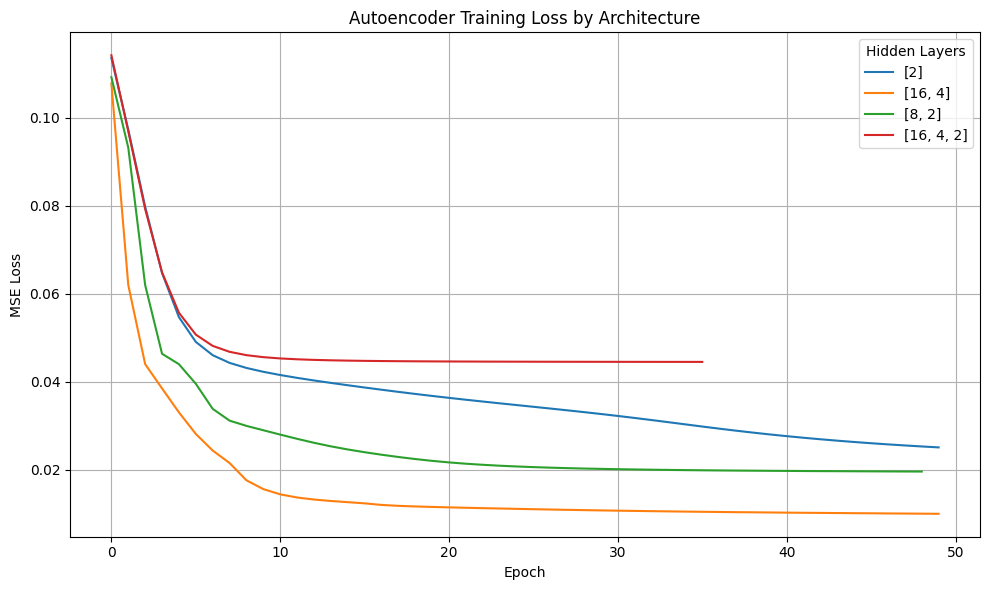

In [215]:
plot_ae_loss_curves(results_minmax)

In [220]:
latent_dims = list(set(hidden_layer_config[-1] for hidden_layer_config in hidden_layers))
logger.info(f"Evaluating PCA and SVD for latent dimensions: {latent_dims}")
pca_results = {}
svd_results = {}
for dim in latent_dims:
    pca_mse_train, pca_mse_val = pca(X_train_scaled, X_val_scaled, n_components=dim)
    svd_mse_train, svd_mse_val = svd(X_train_scaled, X_val_scaled, n_components=dim)
    pca_results[dim] = {'train': pca_mse_train, 'val': pca_mse_val}
    svd_results[dim] = {'train': svd_mse_train, 'val': svd_mse_val}

INFO: Evaluating PCA and SVD for latent dimensions: [2, 4]
INFO: PCA reconstruction MSE (train): 0.023204
INFO: PCA explained variance ratio: 0.478
INFO: PCA reconstruction MSE (val): 0.022723
INFO: SVD reconstruction MSE (train): 0.028283
INFO: SVD explained variance ratio: 0.366
INFO: SVD reconstruction MSE (val): 0.028175
INFO: PCA reconstruction MSE (train): 0.013374
INFO: PCA explained variance ratio: 0.699
INFO: PCA reconstruction MSE (val): 0.013378
INFO: SVD reconstruction MSE (train): 0.016447
INFO: SVD explained variance ratio: 0.631
INFO: SVD reconstruction MSE (val): 0.015883


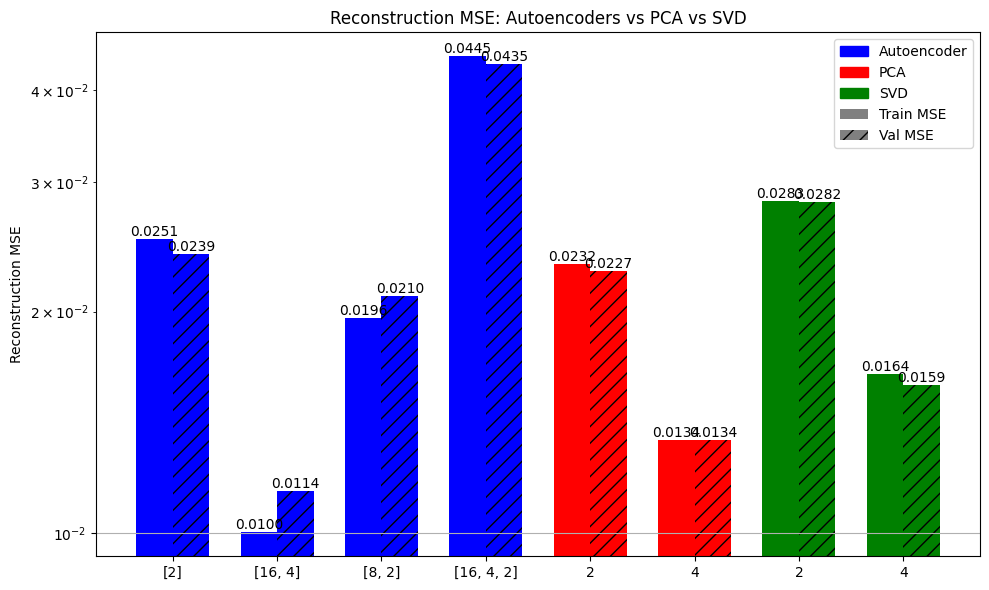

In [229]:
plot_reconstruction_comparison(results_minmax, pca_results, svd_results)

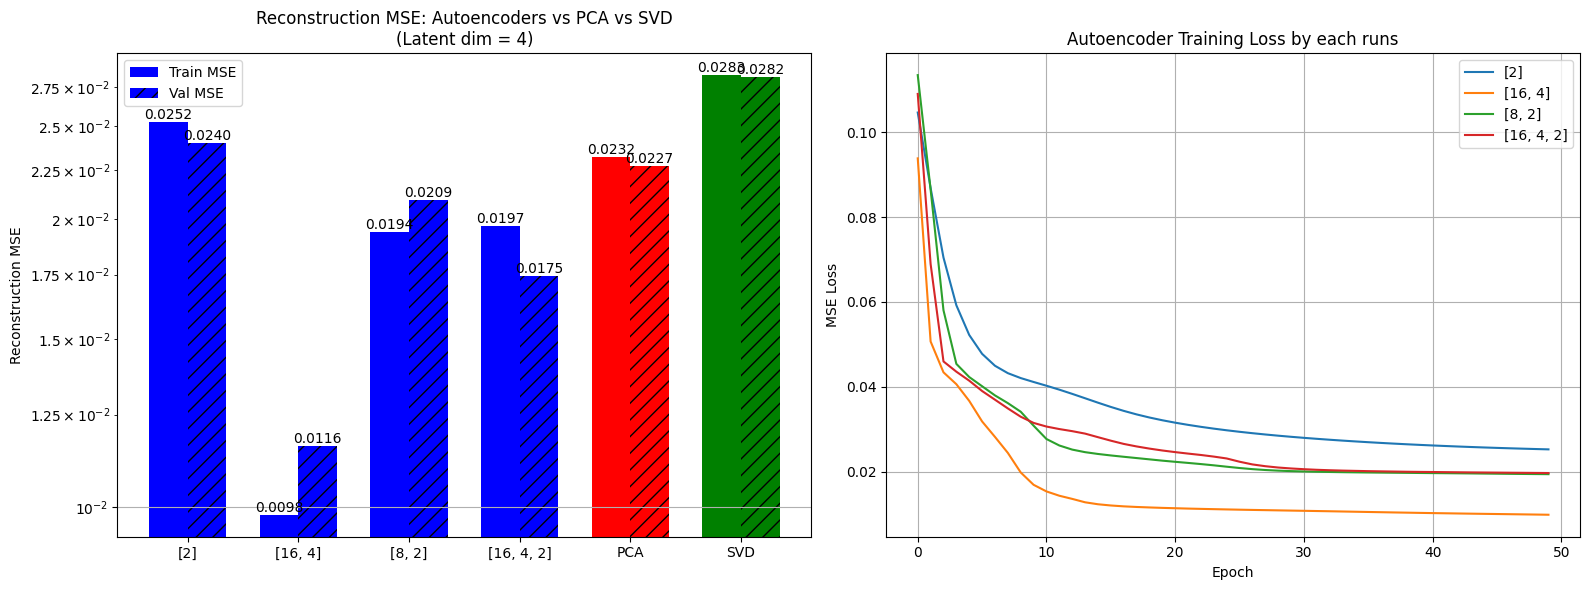

INFO: Method                       Train MSE     Test MSE
INFO: [2]                           0.025239     0.024009
INFO: [16, 4]                       0.009824     0.011577
INFO: [8, 2]                        0.019391     0.020939
INFO: [16, 4, 2]                    0.019658     0.017461
INFO: PCA                           0.023204     0.022723
INFO: SVD                           0.028283     0.028175


In [200]:
compare_results(results, results_minmax)